# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tabassumrafiq/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.



This audit checks whether selected observed content and search signals show directional differences between declining and non-declining content.

The analysis uses simple descriptive comparisons and cautious decision-support language.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [4]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv


In [5]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("File loaded:", file_name)
print("Dataset shape:", df.shape)

display(df.head())

File loaded: content_refresh_anonymized.csv
Dataset shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [6]:
print("First 5 rows:")
display(df.head())

print("\nMissing values:")
missing_values = df.isna().sum().sort_values(ascending=False)

display(missing_values[missing_values > 0])

First 5 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



Missing values:


,0
provider_used,21438
word_count,7699
char_count,7699
word_count_tier,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
cpc,2468


In [7]:
assert "trend_direction" in df.columns

df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
)

print("Declining label counts:")
display(df["is_declining_label"].value_counts())

print("\nDeclining rate:")
print(round(df["is_declining_label"].mean(), 4))

Declining label counts:


,count
is_declining_label,
True,16262
False,13738



Declining rate:
0.5421


### Distribution observation

The observed distributions are inspected before selecting the signal tests. Search-performance fields can be unevenly distributed, so descriptive statistics such as the median are used to reduce the influence of extreme observations.

In [19]:
key_fields = [
    "impressions_90d",
    "avg_position",
    "clicks_90d",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "word_count"
]

available_fields = [
    col for col in key_fields
    if col in df.columns
]

print("Available key fields:")
print(available_fields)

display(df[available_fields].describe().T)

Available key fields:
['impressions_90d', 'avg_position', 'clicks_90d', 'ctr', 'engagement_rate', 'scroll_rate', 'word_count']


,count,mean,std,min,25%,50%,75%,max
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.0
avg_position,30000.0,16.342380,15.216790,0.0,6.2,10.80,22.30,245.0
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.0
ctr,30000.0,0.510733,3.279162,0.0,0.0,0.07,0.29,100.0
engagement_rate,30000.0,2.534520,8.310096,0.0,0.0,0.00,1.35,100.0
scroll_rate,29875.0,18.212921,29.472768,0.0,0.0,5.00,23.53,300.0
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.0


In [20]:
distribution_check = pd.DataFrame({
    "mean": df[available_fields].mean(),
    "median": df[available_fields].median(),
    "std": df[available_fields].std(),
    "min": df[available_fields].min(),
    "max": df[available_fields].max()
})

distribution_check["mean_median_ratio"] = (
    distribution_check["mean"] /
    distribution_check["median"].replace(0, np.nan)
)

display(distribution_check)

,mean,median,std,min,max,mean_median_ratio
impressions_90d,5200.366300,731.00,16838.019547,1.0,517715.0,7.114044
avg_position,16.342380,10.80,15.216790,0.0,245.0,1.513183
clicks_90d,16.097333,1.00,75.076958,0.0,4178.0,16.097333
ctr,0.510733,0.07,3.279162,0.0,100.0,7.296190
engagement_rate,2.534520,0.00,8.310096,0.0,100.0,NaN
scroll_rate,18.212921,5.00,29.472768,0.0,300.0,3.642584
word_count,3107.760325,2877.00,1452.382598,8.0,9546.0,1.080209


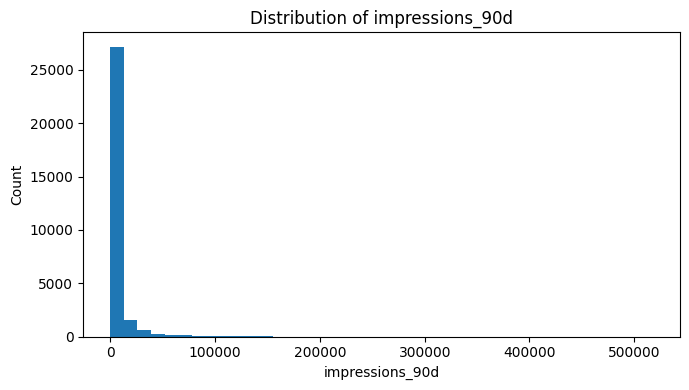

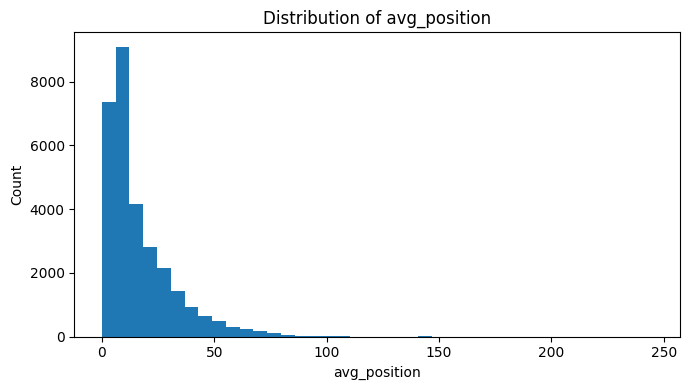

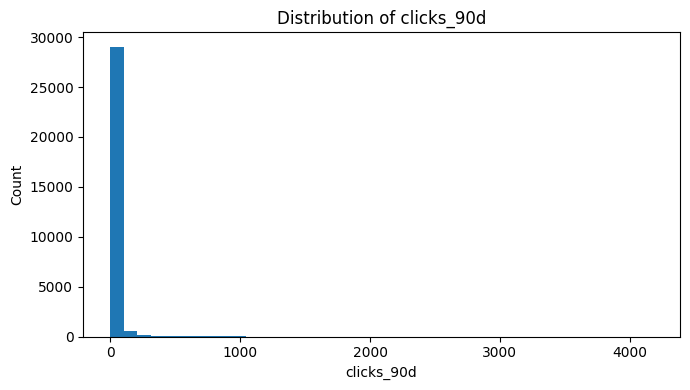

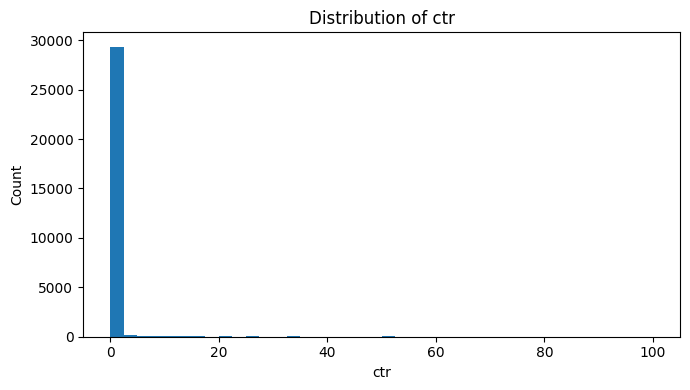

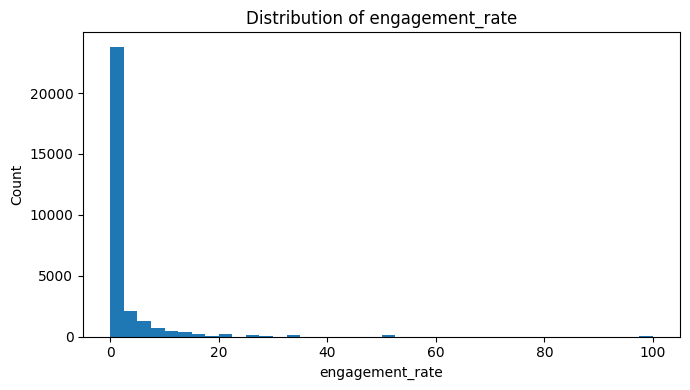

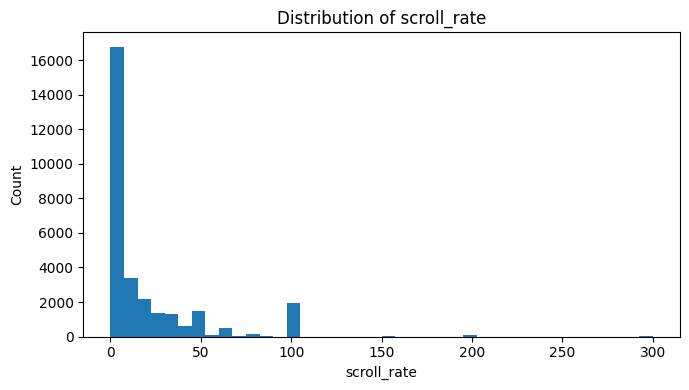

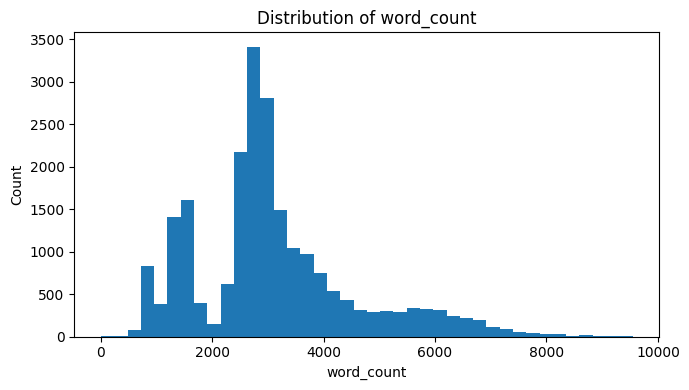

In [21]:
for col in available_fields:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[col].dropna(),
        bins=40
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

# 2. Signal Test #1 — Word Count

I test whether observed word count differs directionally between declining and non-declining content.

In [22]:
df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
)

print("Declining label distribution:")
display(df["is_declining_label"].value_counts())

word_summary = (
    df.groupby("is_declining_label")["word_count"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
)

display(word_summary)

Declining label distribution:


,count
is_declining_label,
True,16262
False,13738


,count,mean,median
is_declining_label,,,
False,9622,2957.452713,2839.0
True,12679,3221.827668,2909.0


In [23]:
word_medians = (
    df.groupby("is_declining_label")["word_count"]
    .median()
)

declining_word = word_medians.loc[True]
non_declining_word = word_medians.loc[False]

word_difference_pct = (
    (declining_word - non_declining_word)
    / non_declining_word
    * 100
)

print("Declining median word count:",
      round(declining_word, 2))

print("Non-declining median word count:",
      round(non_declining_word, 2))

print("Median difference:",
      round(word_difference_pct, 2), "%")

Declining median word count: 2909.0
Non-declining median word count: 2839.0
Median difference: 2.47 %


# 2. Signal Test #2 — Average Position

I test whether declining content has a different observed average search position from non-declining content.

A higher average position value represents a weaker search ranking position.

In [24]:
position_summary = (
    df.groupby("is_declining_label")["avg_position"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
)

display(position_summary)

,count,mean,median
is_declining_label,,,
False,13738,16.823060,10.05
True,16262,15.936305,11.30


In [25]:
position_medians = (
    df.groupby("is_declining_label")["avg_position"]
    .median()
)

declining_position = position_medians.loc[True]
non_declining_position = position_medians.loc[False]

position_difference_pct = (
    (declining_position - non_declining_position)
    / non_declining_position
    * 100
)

print("Declining median position:",
      round(declining_position, 2))

print("Non-declining median position:",
      round(non_declining_position, 2))

print("Median position difference:",
      round(position_difference_pct, 2), "%")

Declining median position: 11.3
Non-declining median position: 10.05
Median position difference: 12.44 %


# 2. Signal Test #3 — GSC Impressions

I test whether observed GSC impressions differ directionally between declining and non-declining content.

Because impressions can be heavy-tailed, the median is an important reference.

In [26]:
impression_summary = (
    df.groupby("is_declining_label")["impressions_90d"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
)

display(impression_summary)

,count,mean,median
is_declining_label,,,
False,13738,5533.310962,472.0
True,16262,4919.097466,961.0


In [27]:
impression_medians = (
    df.groupby("is_declining_label")["impressions_90d"]
    .median()
)

declining_impressions = impression_medians.loc[True]
non_declining_impressions = impression_medians.loc[False]

impression_difference_pct = (
    (declining_impressions - non_declining_impressions)
    / non_declining_impressions
    * 100
)

print("Declining median impressions:",
      round(declining_impressions, 2))

print("Non-declining median impressions:",
      round(non_declining_impressions, 2))

print("Median impressions difference:",
      round(impression_difference_pct, 2), "%")

Declining median impressions: 961.0
Non-declining median impressions: 472.0
Median impressions difference: 103.6 %


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*



The baseline review rule relies on meaningful observed search visibility and weaker average search position.

I test whether the observed data supports this assumption across average-position groups.

In [28]:
df["position_group"] = pd.qcut(
    df["avg_position"],
    q=4,
    duplicates="drop"
)

flag_test = (
    df.groupby(
        "position_group",
        observed=True
    )
    .agg(
        rows=("avg_position", "size"),
        median_impressions=("impressions_90d", "median"),
        median_position=("avg_position", "median"),
        decline_rate=("is_declining_label", "mean")
    )
    .reset_index()
)

display(flag_test)

,position_group,rows,median_impressions,median_position,decline_rate
0,"(-0.001, 6.2]",7543,404.0,4.3,0.461355
1,"(6.2, 10.8]",7534,982.0,8.0,0.579904
2,"(10.8, 22.3]",7462,848.0,15.3,0.610694
3,"(22.3, 245.0]",7461,619.0,33.4,0.516821


In [29]:
print("Best-position group:")
display(flag_test.iloc[0].to_frame().T)

print("\nWeakest-position group:")
display(flag_test.iloc[-1].to_frame().T)

Best-position group:


,position_group,rows,median_impressions,median_position,decline_rate
0,"(-0.001, 6.2]",7543,404.0,4.3,0.461355



Weakest-position group:


,position_group,rows,median_impressions,median_position,decline_rate
3,"(22.3, 245.0]",7461,619.0,33.4,0.516821


### Verdict

The flag-linked result is interpreted from the observed differences between the strongest- and weakest-position groups.

This test checks whether the baseline assumption is directionally supported. It does not prove that weak search position causes content decline.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

## 4. What This Means in Practice

The observed search and content signals can provide directional decision-support for prioritizing content review. They should not be treated as proof that a page is stale or that refreshing it will improve search performance.

Human review should consider additional context such as content quality, search intent, competition, and current page conditions before taking action.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [30]:
signal_columns = [
    "impressions_90d",
    "avg_position",
    "clicks_90d",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "word_count"
]

leakage_terms = [
    "trend",
    "last30",
    "future",
    "outcome",
    "label",
    "needs_refresh",
    "product_flag"
]

possible_leaks = [
    col
    for col in signal_columns
    if any(
        term in col.lower()
        for term in leakage_terms
    )
]

print("Possible leakage columns:")
print(possible_leaks)

assert len(possible_leaks) == 0

print("\nLeakage check passed.")

Possible leakage columns:
[]

Leakage check passed.
